# Copernicus Solar Forecasting — notebook de préparation, audit et EDA

Ce notebook reprend et réorganise le notebook initial dans une version plus propre, plus modulaire et plus robuste pour le projet.

## Objectifs du notebook
- rappeler clairement la problématique du challenge ;
- documenter la structure des données brutes et des cibles ;
- visualiser quelques séquences représentatives ;
- mettre en place des **contrôles qualité reproductibles** ;
- vérifier non seulement le profil `dev`, mais aussi **tous les profils processed disponibles** (`dev`, `sample`, `full`) ;
- préparer les objets utiles pour la suite : split chronologique, standardisation, premières features ;
- produire une base propre pour les notebooks suivants (benchmarks, modèles supervisés, clustering, XAI, deep learning).

## Idée directrice
On distingue ici deux niveaux :
1. **audit global des données** : cohérence des shapes, types, valeurs manquantes, bornes, datetimes, couverture des profils ;
2. **préparation pour la modélisation** : split temporel, standardisation, features tensorielles et premiers constats exploratoires.

> Ce notebook se concentre volontairement sur la préparation et l'exploration.  
> Les modèles, les métriques finales et les comparaisons seront développés dans les notebooks suivants.

In [1]:

# %% Imports et configuration générale

from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)
plt.style.use("default")
warnings.filterwarnings("ignore")

In [2]:

# %% Résolution du PROJECT_ROOT + imports du projet
# Ce bloc essaie d'importer la configuration du projet.
# Si le notebook est déplacé, il tente plusieurs chemins raisonnables.

CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/mnt/data"),
]

PROJECT_ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "config.py").exists() or (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting


In [ ]:

# %% Imports métier
# Si ton projet est structuré avec un package src/, ce bloc doit fonctionner tel quel.
# Sinon, adapte simplement les imports en conséquence.

from config import (
    FORECAST_HORIZONS_MINUTES,
    INPUT_VARIABLES,
    VALIDATION_FRACTION,
    X_TEST_PATH,
    X_TRAIN_PATH,
    Y_TRAIN_PATH,
)

from src.data_loading import (
    array_to_submission,
    extract_roi,
    load_input_sample,
    load_targets,
    npz_array_metadata,
    open_processed_profile,
    prepare_processed_profile,
    processed_profile_exists,
    targets_to_array,
)

from src.eda import (
    descriptive_stats,
    sample_level_means,
    target_horizon_stats,
    temporal_ghi_summary,
)

from src.metrics import (
    rmse,
    mae,
    evaluate_forecasts,
    evaluate_by_horizon,
    evaluate_spatial_means,
)

from src.features import (
    build_physical_inputs,
    build_tabular_features,
    build_spatial_feature_tensor,
    feature_summary,)

from src.preprocessing import (
    fit_standardizer,
    quality_report,
    standardizer_to_frame,
    temporal_train_validation_split,
    transform_with_standardizer,
)

from src.visualization import (
    describe_sample,
    horizon_titles,
    plot_sample_overview,
    plot_sequence,
    plot_value_distribution,
)

from src.utils import describe_numeric_array

## 1. Paramètres du notebook

Le notebook est volontairement **paramétrable** pour permettre :
- une inspection rapide sur `dev`,
- une vérification plus complète sur `sample` ou `full`,
- et un audit global sur tous les profils processed disponibles.

Le point important ici est que l'audit n'est plus limité au seul dataset `dev`.

In [4]:
# %% Paramètres utilisateur

PROFILE_FOR_EDA = "dev"            # profil principal pour visualisations et EDA
PROFILES_TO_AUDIT = ("dev", "sample", "full")
BUILD_MISSING_PROFILES = False     # passer à True pour construire les profils manquants
AUDIT_MAX_SAMPLES_PER_PROFILE = None   # ex. 500 pour un audit rapide ; None = tout le profil
AUDIT_CHUNK_SIZE = 128

SAMPLE_INDEX = 0
N_TARGET_PREVIEW = 5


## 2. Rappel du challenge

On cherche à prévoir le **Global Horizontal Irradiance (GHI)** à très court terme à partir de séquences d'images satellitaires et de variables physiques contextuelles.

### Formulation du problème
À l'instant `t`, on observe :
- les **4 dernières images** de `GHI` sur l'**Observation Region** (OR) de taille `81 x 81`,
- les variables contextuelles `CLS`, `SZA` et `SAA`, disponibles sur 8 pas de temps (passés + futurs).

On veut prédire :
- les **4 prochaines images** de `GHI`
- aux horizons `t+15`, `t+30`, `t+45`, `t+60`
- sur la **Region of Interest** (RoI) centrale de taille `51 x 51`.

### Interprétation ML
Le problème est une **régression spatio-temporelle multi-sortie** :
- entrée : une séquence d'images multicanales,
- sortie : une séquence future d'images.

Cela justifie deux familles d'approches :
- des **features tabulaires** pour des modèles classiques,
- des **tenseurs image/canaux** pour des CNN ou autres modèles deep learning.

## 3. Vue d'ensemble des données brutes

In [5]:

# %% Métadonnées des archives NPZ brutes
metadata = pd.concat(
    [npz_array_metadata(X_TRAIN_PATH), npz_array_metadata(X_TEST_PATH)],
    ignore_index=True,
)
metadata

,file,array,shape,dtype,fortran_order,compression,size_mb
0,X_train_copernicus.npz,datetime,"(1845,)",object,False,stored,0.05
1,X_train_copernicus.npz,GHI,"(1845, 4, 81, 81)",float64,False,stored,369.42
2,X_train_copernicus.npz,CLS,"(1845, 8, 81, 81)",float64,False,stored,738.83
3,X_train_copernicus.npz,SZA,"(1845, 8, 81, 81)",float64,False,stored,738.83
4,X_train_copernicus.npz,SAA,"(1845, 8, 81, 81)",float64,False,stored,738.83
5,X_test_copernicus.npz,datetime,"(1841,)",object,False,stored,0.05
6,X_test_copernicus.npz,GHI,"(1841, 4, 81, 81)",float64,False,stored,368.62
7,X_test_copernicus.npz,CLS,"(1841, 8, 81, 81)",float64,False,stored,737.23
8,X_test_copernicus.npz,SZA,"(1841, 8, 81, 81)",float64,False,stored,737.23
9,X_test_copernicus.npz,SAA,"(1841, 8, 81, 81)",float64,False,stored,737.23


**Lecture attendue des métadonnées**
- le train et le test sont fournis dans deux archives `.npz` distinctes ;
- `GHI` contient 4 images passées ;
- `CLS`, `SZA` et `SAA` contiennent 8 images (passé + futur) ;
- les données sont stockées de manière compatible avec une ouverture en memory mapping, ce qui est utile pour travailler à grande échelle sans charger tout en mémoire.

In [6]:

# %% Structure de la cible
y_preview = load_targets(Y_TRAIN_PATH, nrows=N_TARGET_PREVIEW)
display(y_preview.iloc[:, :8])

y_preview_array = targets_to_array(y_preview)
print("CSV shape   :", y_preview.shape)
print("Array shape :", y_preview_array.shape)

,id_sequence,0,1,2,3,4,5,6
0,0,247.51,261.68,260.16,262.71,264.28,262.55,257.21
1,1,471.37,476.41,474.55,477.96,479.87,477.65,476.65
2,2,458.39,463.38,461.54,464.88,466.76,464.57,463.57
3,3,223.42,228.37,226.91,229.26,230.75,229.11,228.31
4,4,170.23,137.61,136.96,84.42,54.23,53.53,50.55


CSV shape   : (5, 10405)
Array shape : (5, 4, 51, 51)


La cible fournie sous forme tabulaire aplatie est reconstruite en tenseur de forme :

`(n_samples, 4, 51, 51)`

Les 4 plans correspondent aux horizons :
- `t+15`,
- `t+30`,
- `t+45`,
- `t+60` minutes.

In [7]:

# %% Vérification de la transformation aller-retour
y_back_to_csv = array_to_submission(y_preview_array, ids=y_preview["id_sequence"])
print("Back to CSV shape:", y_back_to_csv.shape)
display(y_back_to_csv.iloc[:, :8])

Back to CSV shape: (5, 10405)


,id_sequence,0,1,2,3,4,5,6
0,0,247.509995,261.679993,260.160004,262.709991,264.279999,262.549988,257.209991
1,1,471.369995,476.410004,474.549988,477.959991,479.869995,477.649994,476.649994
2,2,458.390015,463.380005,461.540009,464.880005,466.760010,464.570007,463.570007
3,3,223.419998,228.369995,226.910004,229.259995,230.750000,229.110001,228.309998
4,4,170.229996,137.610001,136.960007,84.419998,54.230000,53.529999,50.549999


## 4. Variables explicatives et zones spatiales

### Variables
- **GHI** : irradiance observée, variable centrale du problème ;
- **CLS** : irradiance de ciel clair, référence physique sans nuages ;
- **SZA** : angle zénithal solaire ;
- **SAA** : angle azimutal solaire.

### Zones
- **OR (Observation Region)** : `81 x 81` pixels ;
- **RoI (Region of Interest)** : `51 x 51` pixels, zone centrale à prédire.

Le recadrage de l'OR vers la RoI permet :
- d'aligner directement les entrées avec la cible,
- de réduire le volume des données,
- tout en conservant la zone de prédiction pertinente.

In [ ]:
# %% Inspection locale d'un sample brut
sample = load_input_sample(X_TRAIN_PATH, sample_index=SAMPLE_INDEX, variables=INPUT_VARIABLES)
display(describe_sample(sample))

,array,shape,dtype,min,p25,median,p75,max,nan_count
0,GHI,"(4, 81, 81)",float64,74.60,129.0275,168.785,208.570,262.54,0
1,CLS,"(8, 81, 81)",float64,99.87,187.4500,270.335,344.755,435.22,0
2,SZA,"(8, 81, 81)",float64,127.11,132.1900,137.720,143.710,150.14,0
3,SAA,"(8, 81, 81)",float64,65.48,69.4800,73.260,77.490,82.42,0


In [ ]:
# %% Vérification OR -> RoI
ghi_roi = extract_roi(sample["GHI"])
print("Shape GHI brut :", sample["GHI"].shape)
print("Shape GHI RoI  :", ghi_roi.shape)

Shape GHI brut : (4, 81, 81)
Shape GHI RoI  : (4, 51, 51)


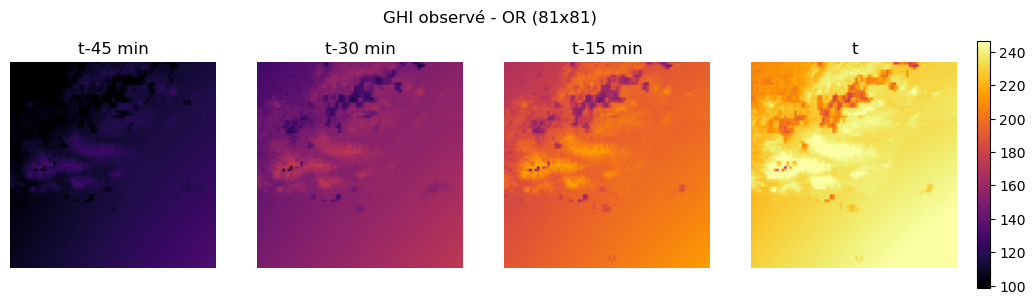

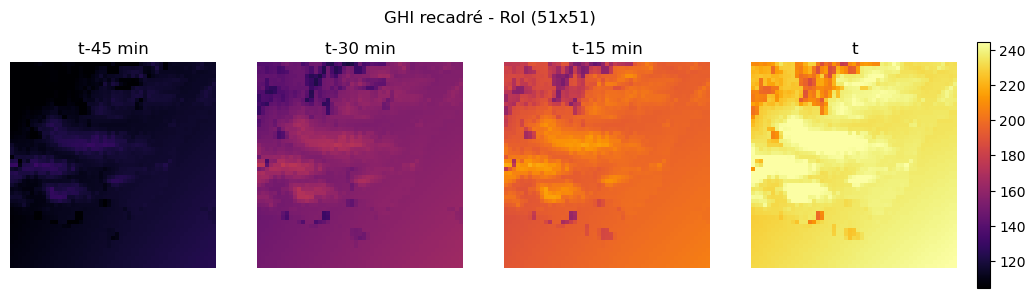

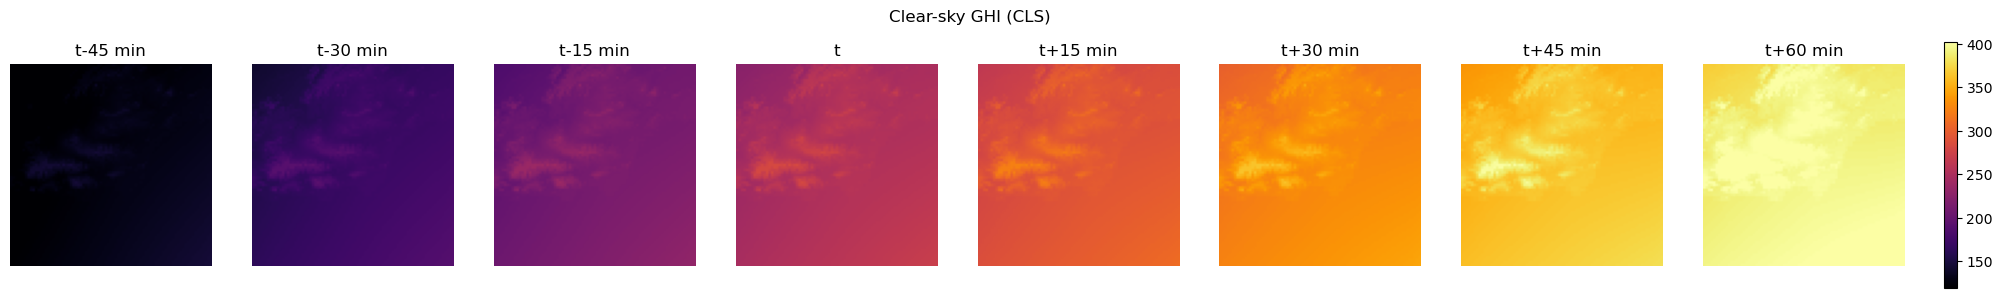

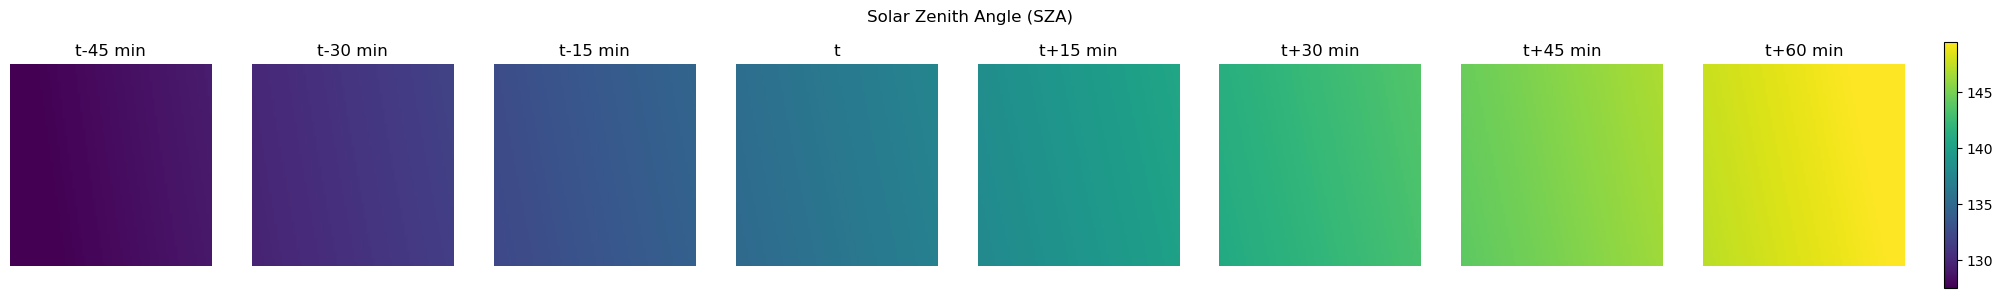

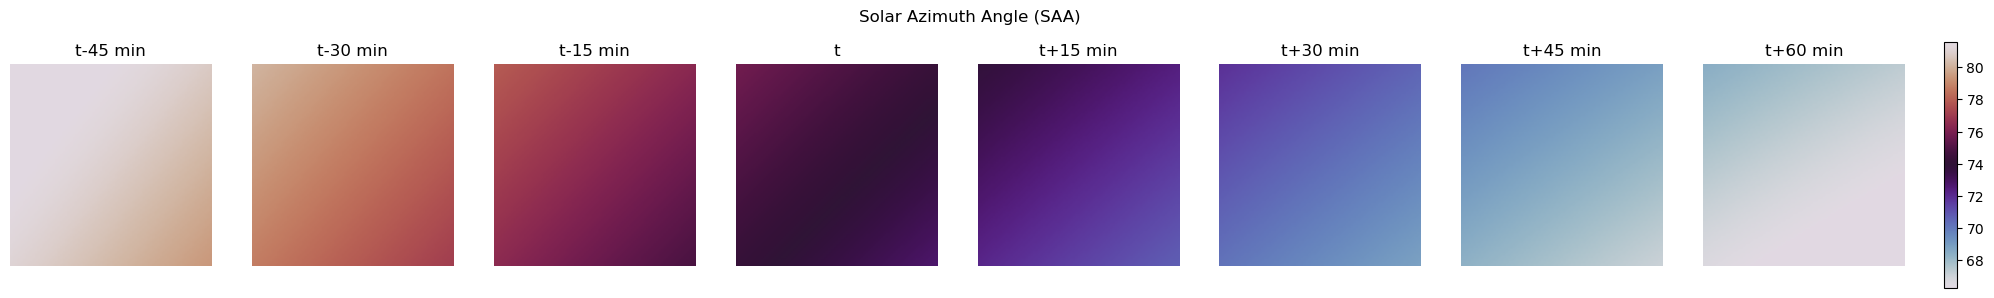

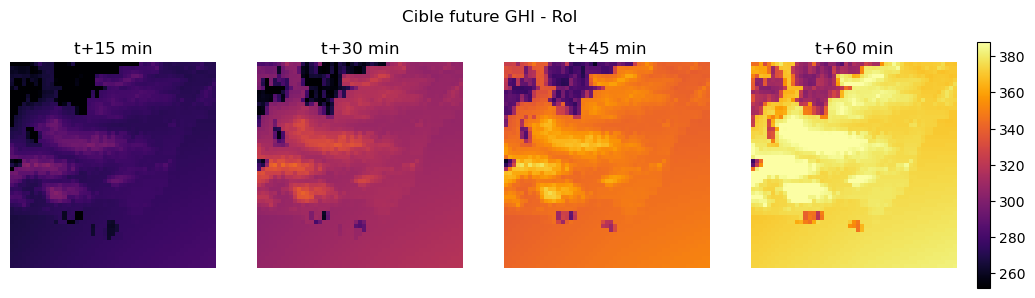

In [10]:

# %% Visualisation d'un exemple
past_titles = ["t-45 min", "t-30 min", "t-15 min", "t"]
context_titles = ["t-45 min", "t-30 min", "t-15 min", "t", "t+15 min", "t+30 min", "t+45 min", "t+60 min"]

target_rows = load_targets(Y_TRAIN_PATH, nrows=SAMPLE_INDEX + 1)
target = targets_to_array(target_rows.iloc[[SAMPLE_INDEX]])[0]

plot_sequence(sample["GHI"], titles=past_titles, n_steps=4, suptitle="GHI observé - OR (81x81)")
plot_sequence(ghi_roi, titles=past_titles, n_steps=4, suptitle="GHI recadré - RoI (51x51)")
plot_sequence(sample["CLS"], titles=context_titles, n_steps=8, suptitle="Clear-sky GHI (CLS)")
plot_sequence(sample["SZA"], titles=context_titles, n_steps=8, cmap="viridis", suptitle="Solar Zenith Angle (SZA)")
plot_sequence(sample["SAA"], titles=context_titles, n_steps=8, cmap="twilight", suptitle="Solar Azimuth Angle (SAA)")
plot_sequence(target, titles=horizon_titles(FORECAST_HORIZONS_MINUTES), n_steps=4, suptitle="Cible future GHI - RoI")
plt.show()

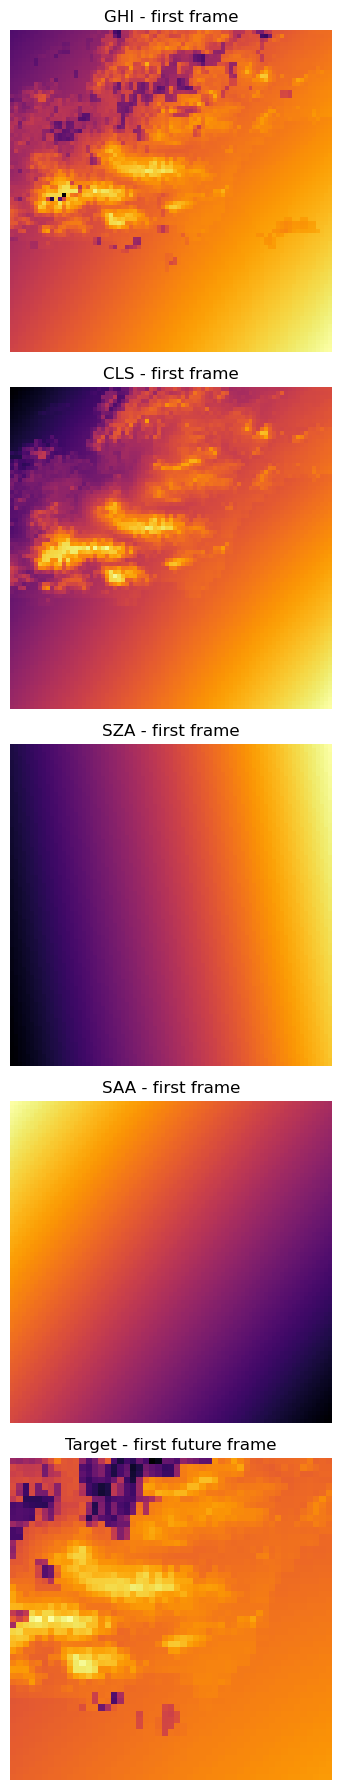

In [ ]:
# %% Vue synthétique
plot_sample_overview(sample, target)
plt.show()

## 5. Fonctions d'audit global des données

Cette section est le point clé ajouté par rapport au notebook initial.

L'objectif est de pouvoir :
- auditer un **sample**,
- auditer un **profil processed** complet ou partiel,
- et surtout **vérifier plusieurs profils** (`dev`, `sample`, `full`) de manière homogène.

On sépare :
1. les vérifications **structurelles** : shapes, dtypes, présence des fichiers, manifest ;
2. les vérifications **numériques** : `NaN`, `Inf`, min/max, quantiles ;
3. les vérifications **temporelles** : unicité, ordre croissant, doublons ;
4. les vérifications **par split** : train vs validation.

In [12]:

# %% Outils d'audit chunké

def subset_indices(n_samples: int, max_samples: int | None = None) -> np.ndarray:
    if max_samples is None or max_samples >= n_samples:
        return np.arange(n_samples, dtype=int)
    return np.arange(max_samples, dtype=int)


def datetime_checks(datetime_values) -> pd.DataFrame:
    dt = pd.to_datetime(pd.Series(datetime_values))
    return pd.DataFrame(
        {
            "check": [
                "n_datetimes",
                "n_unique_datetimes",
                "is_unique",
                "is_monotonic_increasing",
                "has_duplicates",
                "min_datetime",
                "max_datetime",
            ],
            "value": [
                len(dt),
                dt.nunique(),
                dt.nunique() == len(dt),
                dt.is_monotonic_increasing,
                dt.duplicated().any(),
                dt.min(),
                dt.max(),
            ],
        }
    )


def summarize_array_in_chunks(name: str, array: np.ndarray, chunk_size: int = 128) -> dict[str, object]:
    n = len(array)
    nan_count = 0
    inf_count = 0
    finite_min = np.inf
    finite_max = -np.inf

    for start in range(0, n, chunk_size):
        chunk = np.asarray(array[start : start + chunk_size])
        if np.issubdtype(chunk.dtype, np.number):
            nan_count += int(np.isnan(chunk).sum())
            inf_count += int(np.isinf(chunk).sum())
            finite = chunk[np.isfinite(chunk)]
            if finite.size:
                finite_min = min(finite_min, float(finite.min()))
                finite_max = max(finite_max, float(finite.max()))

    if finite_min == np.inf:
        finite_min = np.nan
    if finite_max == -np.inf:
        finite_max = np.nan

    return {
        "array": name,
        "shape": tuple(array.shape),
        "dtype": str(array.dtype),
        "nan_count": nan_count,
        "inf_count": inf_count,
        "min": finite_min,
        "max": finite_max,
    }


def quick_profile_structure(profile_data: dict[str, object]) -> pd.DataFrame:
    rows = []
    for name, arr in profile_data["X"].items():
        rows.append(
            {
                "array": name,
                "shape": arr.shape,
                "dtype": str(arr.dtype),
                "is_memmap": isinstance(arr, np.memmap),
            }
        )
    if "y" in profile_data:
        rows.append(
            {
                "array": "y",
                "shape": profile_data["y"].shape,
                "dtype": str(profile_data["y"].dtype),
                "is_memmap": isinstance(profile_data["y"], np.memmap),
            }
        )
    return pd.DataFrame(rows)


def audit_processed_profile(
    profile: str,
    split: str = "train",
    max_samples: int | None = None,
    chunk_size: int = 128,
) -> dict[str, pd.DataFrame]:
    data = open_processed_profile(profile, split=split)

    idx = subset_indices(len(data["indices"]), max_samples=max_samples)
    x_subset = {name: values[idx] for name, values in data["X"].items()}
    y_subset = data["y"][idx] if "y" in data else None
    dt_subset = pd.to_datetime(pd.Series(data["datetime"][idx]))

    structure = quick_profile_structure(data)
    manifest = pd.DataFrame([data["manifest"]])

    quality_rows = []
    for name, arr in x_subset.items():
        quality_rows.append(summarize_array_in_chunks(name, arr, chunk_size=chunk_size))
    if y_subset is not None:
        quality_rows.append(summarize_array_in_chunks("y", y_subset, chunk_size=chunk_size))
    quality = pd.DataFrame(quality_rows)

    scales_rows = [describe_numeric_array(name, arr) for name, arr in x_subset.items()]
    if y_subset is not None:
        scales_rows.append(describe_numeric_array("y", y_subset))
    scales = pd.DataFrame(scales_rows)

    datetimes = datetime_checks(dt_subset)

    return {
        "manifest": manifest,
        "structure": structure,
        "quality": quality,
        "scales": scales,
        "datetimes": datetimes,
    }


def audit_all_available_profiles(
    profiles=("dev", "sample", "full"),
    splits=("train", "test"),
    max_samples: int | None = None,
    chunk_size: int = 128,
) -> pd.DataFrame:
    rows = []
    for profile in profiles:
        for split in splits:
            exists = processed_profile_exists(profile, split=split)
            if not exists:
                rows.append(
                    {
                        "profile": profile,
                        "split": split,
                        "exists": False,
                        "n_samples": np.nan,
                        "n_arrays": np.nan,
                        "has_target": np.nan,
                        "datetime_unique": np.nan,
                        "datetime_monotonic": np.nan,
                        "total_nan_count": np.nan,
                        "total_inf_count": np.nan,
                    }
                )
                continue

            report = audit_processed_profile(
                profile=profile,
                split=split,
                max_samples=max_samples,
                chunk_size=chunk_size,
            )
            manifest = report["manifest"].iloc[0]
            quality = report["quality"]
            dt = report["datetimes"].set_index("check")["value"]

            rows.append(
                {
                    "profile": profile,
                    "split": split,
                    "exists": True,
                    "n_samples": manifest["n_samples"],
                    "n_arrays": len(report["structure"]),
                    "has_target": "y" in report["structure"]["array"].tolist(),
                    "datetime_unique": bool(dt["is_unique"]),
                    "datetime_monotonic": bool(dt["is_monotonic_increasing"]),
                    "total_nan_count": int(quality["nan_count"].sum()),
                    "total_inf_count": int(quality["inf_count"].sum()),
                }
            )
    return pd.DataFrame(rows)

## 6. Création optionnelle des profils processed

Tu peux garder `BUILD_MISSING_PROFILES = False` pour éviter de lancer une préparation lourde.
Quand le pipeline est stabilisé, tu peux passer ce paramètre à `True` pour construire automatiquement les profils manquants.

L'avantage est d'avoir ensuite un audit homogène sur `dev`, `sample` et `full`.

In [13]:

# %% Construction optionnelle des profils manquants

if BUILD_MISSING_PROFILES:
    for profile_name in PROFILES_TO_AUDIT:
        if not processed_profile_exists(profile_name, split="train"):
            print(f"Construction de {profile_name}/train ...")
            prepare_processed_profile(profile_name, split="train")
        if not processed_profile_exists(profile_name, split="test"):
            print(f"Construction de {profile_name}/test ...")
            prepare_processed_profile(profile_name, split="test", include_target=False)
else:
    print("BUILD_MISSING_PROFILES = False -> aucune construction lancée.")

BUILD_MISSING_PROFILES = False -> aucune construction lancée.


## 7. Audit global de tous les profils disponibles

C'est ici que l'on répond explicitement au besoin : **vérifier toutes les données, pas seulement `dev`**.

Le tableau ci-dessous donne une vue synthétique :
- existence des profils,
- présence de la cible,
- cohérence temporelle,
- présence éventuelle de `NaN` / `Inf`.

In [14]:

# %% Tableau de synthèse global
audit_summary = audit_all_available_profiles(
    profiles=PROFILES_TO_AUDIT,
    splits=("train", "test"),
    max_samples=AUDIT_MAX_SAMPLES_PER_PROFILE,
    chunk_size=AUDIT_CHUNK_SIZE,
)
audit_summary

,profile,split,exists,n_samples,n_arrays,has_target,datetime_unique,datetime_monotonic,total_nan_count,total_inf_count
0,dev,train,True,32.0,5.0,True,True,True,0.0,0.0
1,dev,test,True,32.0,4.0,False,True,True,0.0,0.0
2,sample,train,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sample,test,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,full,train,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,full,test,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Audit détaillé d'un profil

On garde ensuite un bloc détaillé pour inspecter précisément un profil donné.
Par défaut, on travaille sur `PROFILE_FOR_EDA`, mais le code reste générique.

In [15]:

# %% Audit détaillé du profil principal
profile_report = audit_processed_profile(
    profile=PROFILE_FOR_EDA,
    split="train",
    max_samples=AUDIT_MAX_SAMPLES_PER_PROFILE,
    chunk_size=AUDIT_CHUNK_SIZE,
)

print("Manifest")
display(profile_report["manifest"])

print("Structure")
display(profile_report["structure"])

print("Qualité")
display(profile_report["quality"])

print("Ordres de grandeur")
display(profile_report["scales"])

print("Datetimes")
display(profile_report["datetimes"])

Manifest


,profile,split,description,n_samples,indices,variables,dtype,crop_roi,roi,source_npz,x_paths,target_path
0,dev,train,Tiny deterministic subset for code development and notebook checks.,32,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]","[GHI, CLS, SZA, SAA]",float32,True,"[15, 66]",C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting\da...,{'GHI': 'C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forec...,C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting\da...


Structure


,array,shape,dtype,is_memmap
0,GHI,"(32, 4, 51, 51)",float32,True
1,CLS,"(32, 8, 51, 51)",float32,True
2,SZA,"(32, 8, 51, 51)",float32,True
3,SAA,"(32, 8, 51, 51)",float32,True
4,y,"(32, 4, 51, 51)",float32,True


Qualité


,array,shape,dtype,nan_count,inf_count,min,max
0,GHI,"(32, 4, 51, 51)",float32,0,0,17.889999,580.979980
1,CLS,"(32, 8, 51, 51)",float32,0,0,95.919998,609.080017
2,SZA,"(32, 8, 51, 51)",float32,0,0,126.449997,233.279999
3,SAA,"(32, 8, 51, 51)",float32,0,0,58.700001,82.550003
4,y,"(32, 4, 51, 51)",float32,0,0,26.430000,579.729980


Ordres de grandeur


,array,shape,dtype,min,p25,median,p75,max,nan_count
0,GHI,"(32, 4, 51, 51)",float32,17.889999,246.240005,380.309998,474.529999,580.979980,0
1,CLS,"(32, 8, 51, 51)",float32,95.919998,279.720001,421.739990,511.920013,609.080017,0
2,SZA,"(32, 8, 51, 51)",float32,126.449997,149.975006,180.184998,210.162506,233.279999,0
3,SAA,"(32, 8, 51, 51)",float32,58.700001,61.450001,66.139999,73.320000,82.550003,0
4,y,"(32, 4, 51, 51)",float32,26.430000,242.779999,382.890015,474.140015,579.729980,0


Datetimes


,check,value
0,n_datetimes,32
1,n_unique_datetimes,32
2,is_unique,True
3,is_monotonic_increasing,True
4,has_duplicates,False
5,min_datetime,2012-01-01 09:15:00
6,max_datetime,2012-01-08 15:15:00


**Ce qu'on veut vérifier ici**
- aucune valeur manquante ou infinie ;
- shapes cohérentes après recadrage ;
- dtypes adaptés au calcul (`float32` dans les profils processed) ;
- datetimes uniques et croissants ;
- absence d'incohérence manifeste entre train et test.

## 8. Split train / validation chronologique

Comme il s'agit d'un problème temporel de prévision, le split doit rester **chronologique**.
On évite ainsi une fuite d'information qui apparaîtrait avec un mélange aléatoire des séquences.

In [16]:

# %% Ouverture du profil principal
data = open_processed_profile(PROFILE_FOR_EDA, split="train")
datetimes = pd.to_datetime(pd.Series(data["datetime"]))

train_idx, val_idx = temporal_train_validation_split(
    n_samples=len(data["indices"]),
    validation_fraction=VALIDATION_FRACTION,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation"],
        "n_samples": [len(train_idx), len(val_idx)],
        "first_index": [train_idx[0], val_idx[0]],
        "last_index": [train_idx[-1], val_idx[-1]],
        "min_datetime": [datetimes.iloc[train_idx].min(), datetimes.iloc[val_idx].min()],
        "max_datetime": [datetimes.iloc[train_idx].max(), datetimes.iloc[val_idx].max()],
        "is_monotonic_increasing": [
            datetimes.iloc[train_idx].is_monotonic_increasing,
            datetimes.iloc[val_idx].is_monotonic_increasing,
        ],
    }
)
split_summary

,split,n_samples,first_index,last_index,min_datetime,max_datetime,is_monotonic_increasing
0,train,25,0,24,2012-01-01 09:15:00,2012-01-07 09:15:00,True
1,validation,7,25,31,2012-01-07 11:15:00,2012-01-08 15:15:00,True


In [17]:

# %% Contrôle qualité séparé train / validation
train_arrays = {name: values[train_idx] for name, values in data["X"].items()}
val_arrays = {name: values[val_idx] for name, values in data["X"].items()}

train_target = data["y"][train_idx]
val_target = data["y"][val_idx]

print("Contrôle qualité - train")
display(quality_report(train_arrays, y=train_target))

print("Contrôle qualité - validation")
display(quality_report(val_arrays, y=val_target))

Contrôle qualité - train


,array,shape,dtype,nan_count,inf_count,min,max
0,GHI,"(25, 4, 51, 51)",float32,0,0,17.889999,575.539978
1,CLS,"(25, 8, 51, 51)",float32,0,0,95.919998,605.140015
2,SZA,"(25, 8, 51, 51)",float32,0,0,126.610001,233.270004
3,SAA,"(25, 8, 51, 51)",float32,0,0,58.950001,82.550003
4,y,"(25, 4, 51, 51)",float32,0,0,34.930000,574.559998


Contrôle qualité - validation


,array,shape,dtype,nan_count,inf_count,min,max
0,GHI,"(7, 4, 51, 51)",float32,0,0,35.200001,580.979980
1,CLS,"(7, 8, 51, 51)",float32,0,0,110.730003,609.080017
2,SZA,"(7, 8, 51, 51)",float32,0,0,126.449997,233.279999
3,SAA,"(7, 8, 51, 51)",float32,0,0,58.700001,81.820000
4,y,"(7, 4, 51, 51)",float32,0,0,26.430000,579.729980


Ce split est surtout utilisé ici pour le développement et l'exploration.
Le split final des expériences doit ensuite être reproduit proprement sur un profil plus large (`sample` ou `full`).

## 9. Représentation physique et standardisation

Avant de construire les features de modélisation, on transforme les variables brutes en une représentation plus fidèle à la physique du problème.

L'idée centrale est de remplacer le `GHI` brut par un **clear-sky index** :

\[
CSI = \frac{GHI}{CLS}
\]

où `CLS` représente l'irradiance de ciel clair, c'est-à-dire la référence théorique sans nuage.  
Cette transformation permet d'isoler plus directement l'effet nuageux, en réduisant l'effet déterministe de la géométrie solaire.

Les angles solaires sont eux aussi retravaillés :
- plutôt que d'utiliser directement `SZA` et `SAA`,
- on encode leur structure angulaire avec des couples `sin` / `cos`,
- ce qui évite de traiter comme très éloignés deux angles pourtant proches sur le cercle.

Une fois cette représentation physique construite, la standardisation statistique est ajustée **sur le train uniquement**, puis appliquée au train et à la validation.

### Encodage des angles solaires

Les angles solaires (`SZA`, `SAA`) sont des variables circulaires.  
Une représentation brute peut être trompeuse, car deux angles proches sur le cercle peuvent apparaître très éloignés numériquement.

Pour mieux respecter cette structure, on utilise un encodage en `sin` / `cos` :

\[
\theta \mapsto (\sin(\theta), \cos(\theta))
\]

Cet encodage est particulièrement utile pour `SAA` (azimut solaire), mais il est aussi appliqué à `SZA` pour garder une représentation homogène des variables géométriques.

On standardise ensuite ces canaux comme les autres variables du pipeline.

In [18]:
train_arrays_raw = {name: values[train_idx] for name, values in data["X"].items()}
val_arrays_raw = {name: values[val_idx] for name, values in data["X"].items()}

train_arrays_phys = build_physical_inputs(train_arrays_raw, keep_raw_ghi=False)
val_arrays_phys = build_physical_inputs(val_arrays_raw, keep_raw_ghi=False)

standardizer = fit_standardizer(
    train_arrays_phys,
    variables=train_arrays_phys.keys(),
)

train_arrays_std = transform_with_standardizer(train_arrays_phys, standardizer)
val_arrays_std = transform_with_standardizer(val_arrays_phys, standardizer)

In [19]:

# %% Vérification de la recentration / remise à l'échelle
display(descriptive_stats(train_arrays_std))

,variable,shape,mean,std,min,median,max
0,CSI,"(25, 4, 51, 51)",-9.386414e-08,1.0,-8.582390,0.375854,0.628001
1,CLS,"(25, 8, 51, 51)",7.509131e-08,1.0,-2.133610,0.196678,1.646549
2,SZA_sin,"(25, 8, 51, 51)",0.000000e+00,1.0,-1.553083,0.021906,1.467179
3,SZA_cos,"(25, 8, 51, 51)",-1.614463e-07,1.0,-1.276408,-0.109466,1.891008
4,SAA_sin,"(25, 8, 51, 51)",-2.665741e-07,1.0,-1.543008,-0.057016,1.695760
5,SAA_cos,"(25, 8, 51, 51)",7.509131e-09,1.0,-2.168533,0.216782,1.299669


In [20]:
print("Contrôle qualité - représentation physique train")
display(quality_report(train_arrays_phys, y=train_target))

print("Contrôle qualité - représentation physique standardisée train")
display(quality_report(train_arrays_std, y=train_target))

Contrôle qualité - représentation physique train


,array,shape,dtype,nan_count,inf_count,min,max
0,CSI,"(25, 4, 51, 51)",float32,0,0,0.103893,0.961201
1,CLS,"(25, 8, 51, 51)",float32,0,0,95.919998,605.140015
2,SZA_sin,"(25, 8, 51, 51)",float32,0,0,-0.801463,0.802713
3,SZA_cos,"(25, 8, 51, 51)",float32,0,0,-0.999963,-0.596365
4,SAA_sin,"(25, 8, 51, 51)",float32,0,0,0.856718,0.991558
5,SAA_cos,"(25, 8, 51, 51)",float32,0,0,0.129661,0.515786
6,y,"(25, 4, 51, 51)",float32,0,0,34.930000,574.559998


Contrôle qualité - représentation physique standardisée train


,array,shape,dtype,nan_count,inf_count,min,max
0,CSI,"(25, 4, 51, 51)",float32,0,0,-8.582390,0.628001
1,CLS,"(25, 8, 51, 51)",float32,0,0,-2.133610,1.646549
2,SZA_sin,"(25, 8, 51, 51)",float32,0,0,-1.553083,1.467179
3,SZA_cos,"(25, 8, 51, 51)",float32,0,0,-1.276408,1.891008
4,SAA_sin,"(25, 8, 51, 51)",float32,0,0,-1.543008,1.695760
5,SAA_cos,"(25, 8, 51, 51)",float32,0,0,-2.168533,1.299669
6,y,"(25, 4, 51, 51)",float32,0,0,34.930000,574.559998


## 10. Construction des features et représentation pour la modélisation

Pour préparer des modèles solides, on distingue trois niveaux de représentation :

### Niveau 1 — Représentation physique
On construit d'abord des variables physiquement informées, plus adaptées au problème que les canaux bruts seuls :
- **CSI** (*clear-sky index*) = `GHI / CLS` sur les pas passés, pour isoler l'effet nuageux ;
- **CLS** sur les 8 pas de temps, pour conserver l'information de référence sans nuage ;
- **angles solaires encodés** en `sin` / `cos`, afin de mieux représenter leur caractère circulaire.
 
Cette étape correspond au niveau le plus proche de la physique du problème.

### Niveau 2 — Représentation tensorielle
On construit ensuite un **tenseur channel-first** destiné aux modèles spatiaux :
- `CSI`,
- `CLS`,
- angles encodés,
- deltas temporels de `CSI`,
- et éventuellement des écarts à la situation de ciel clair.

Cette représentation est adaptée aux CNN et plus généralement aux modèles manipulant des tenseurs image.

### Niveau 3 — Représentation tabulaire
Enfin, on prépare aussi une représentation **agrégée en DataFrame** pour :
- les modèles classiques (Ridge, Random Forest, XGBoost, SVM),
- le clustering,
- et les méthodes d'interprétabilité plus simples à appliquer sur des variables tabulaires.

On y retrouve par exemple :
- moyennes spatiales,
- écarts-types,
- quantiles,
- tendances temporelles,
- résumés par quadrants.

Cette séparation rend le pipeline plus propre et plus robuste :
- la physique est traitée avant la standardisation ;
- les features CNN et tabulaires sont construites séparément ;
- la suite du projet pourra réutiliser ces trois niveaux sans dupliquer les transformations.

In [21]:
# %% Niveau 1 - représentation physique standardisée

print("Variables physiques standardisées disponibles :", list(train_arrays_std.keys()))
display(standardizer_to_frame(standardizer))
display(descriptive_stats(train_arrays_std))

Variables physiques standardisées disponibles : ['CSI', 'CLS', 'SZA_sin', 'SZA_cos', 'SAA_sin', 'SAA_cos']


,variable,mean,std
0,CSI,0.902746,0.093081
1,CLS,383.335704,134.708646
2,SZA_sin,0.023439,0.531138
3,SZA_cos,-0.837321,0.127422
4,SAA_sin,0.920958,0.041633
5,SAA_cos,0.371090,0.111333


,variable,shape,mean,std,min,median,max
0,CSI,"(25, 4, 51, 51)",-9.386414e-08,1.0,-8.582390,0.375854,0.628001
1,CLS,"(25, 8, 51, 51)",7.509131e-08,1.0,-2.133610,0.196678,1.646549
2,SZA_sin,"(25, 8, 51, 51)",0.000000e+00,1.0,-1.553083,0.021906,1.467179
3,SZA_cos,"(25, 8, 51, 51)",-1.614463e-07,1.0,-1.276408,-0.109466,1.891008
4,SAA_sin,"(25, 8, 51, 51)",-2.665741e-07,1.0,-1.543008,-0.057016,1.695760
5,SAA_cos,"(25, 8, 51, 51)",7.509131e-09,1.0,-2.168533,0.216782,1.299669


In [22]:
# %% Niveau 2 - tenseur spatial pour CNN / modèles image

feature_tensor, feature_names = build_spatial_feature_tensor(
    train_arrays_std,
    include_csi=True,
    include_cls=True,
    include_angles=True,
    include_csi_deltas=True,
    include_csi_anomaly=True,
    include_raw_ghi=False,
)

display(pd.DataFrame([feature_summary(feature_tensor, feature_names)]))

print("Feature tensor shape :", feature_tensor.shape)
print("Nombre de canaux     :", feature_tensor.shape[1])
print("Présence de NaN      :", np.isnan(feature_tensor).sum())
print("Présence de Inf      :", np.isinf(feature_tensor).sum())
print("Premiers noms        :", feature_names[:20])

,shape,n_features,first_features
0,"(25, 51, 51, 51)",51,"[CSI_t0, CSI_t1, CSI_t2, CSI_t3, CLS_t0, CLS_t1, CLS_t2, CLS_t3, CLS_t4, CLS_t5, CLS_t6, CLS_t7, SZA_sin_t0, SZA_sin..."


Feature tensor shape : (25, 51, 51, 51)
Nombre de canaux     : 51
Présence de NaN      : 0
Présence de Inf      : 0
Premiers noms        : ['CSI_t0', 'CSI_t1', 'CSI_t2', 'CSI_t3', 'CLS_t0', 'CLS_t1', 'CLS_t2', 'CLS_t3', 'CLS_t4', 'CLS_t5', 'CLS_t6', 'CLS_t7', 'SZA_sin_t0', 'SZA_sin_t1', 'SZA_sin_t2', 'SZA_sin_t3', 'SZA_sin_t4', 'SZA_sin_t5', 'SZA_sin_t6', 'SZA_sin_t7']


In [23]:
# %% Tableau de synthèse des blocs tensoriels

feature_blocks = []

if "CSI" in train_arrays_std:
    feature_blocks.append(
        {
            "feature_block": "CSI",
            "n_channels": int(train_arrays_std["CSI"].shape[1]),
            "intuition": "Irradiance observée normalisée par le ciel clair ; isole principalement l'effet nuageux",
        }
    )

if "CLS" in train_arrays_std:
    feature_blocks.append(
        {
            "feature_block": "CLS",
            "n_channels": int(train_arrays_std["CLS"].shape[1]),
            "intuition": "Référence physique sans nuage, utile pour contextualiser le niveau attendu d'irradiance",
        }
    )

for angle_name, angle_desc in [
    ("SZA_sin", "Encodage sinusoïdal de l'angle zénithal"),
    ("SZA_cos", "Encodage cosinus de l'angle zénithal"),
    ("SAA_sin", "Encodage sinusoïdal de l'angle azimutal"),
    ("SAA_cos", "Encodage cosinus de l'angle azimutal"),
]:
    if angle_name in train_arrays_std:
        feature_blocks.append(
            {
                "feature_block": angle_name,
                "n_channels": int(train_arrays_std[angle_name].shape[1]),
                "intuition": angle_desc,
            }
        )

if "CSI" in train_arrays_std:
    feature_blocks.append(
        {
            "feature_block": "CSI_deltas",
            "n_channels": int(train_arrays_std["CSI"].shape[1] - 1),
            "intuition": "Variations temporelles récentes du clear-sky index",
        }
    )
    feature_blocks.append(
        {
            "feature_block": "CSI_minus_1",
            "n_channels": int(train_arrays_std["CSI"].shape[1]),
            "intuition": "Écart à la situation de ciel clair parfait (CSI = 1)",
        }
    )

display(pd.DataFrame(feature_blocks))

,feature_block,n_channels,intuition
0,CSI,4,Irradiance observée normalisée par le ciel clair ; isole principalement l'effet nuageux
1,CLS,8,"Référence physique sans nuage, utile pour contextualiser le niveau attendu d'irradiance"
2,SZA_sin,8,Encodage sinusoïdal de l'angle zénithal
3,SZA_cos,8,Encodage cosinus de l'angle zénithal
4,SAA_sin,8,Encodage sinusoïdal de l'angle azimutal
5,SAA_cos,8,Encodage cosinus de l'angle azimutal
6,CSI_deltas,3,Variations temporelles récentes du clear-sky index
7,CSI_minus_1,4,Écart à la situation de ciel clair parfait (CSI = 1)


In [24]:
# %% Niveau 3 - features tabulaires pour modèles classiques / clustering / XAI

tabular_features_train = build_tabular_features(train_arrays_std)
tabular_features_val = build_tabular_features(val_arrays_std)

print("Tabular train shape :", tabular_features_train.shape)
print("Tabular val shape   :", tabular_features_val.shape)

display(tabular_features_train.head())

Tabular train shape : (25, 502)
Tabular val shape   : (7, 502)


,CSI_mean_t0,CSI_std_t0,CSI_min_t0,CSI_max_t0,CSI_mean_t1,CSI_std_t1,CSI_min_t1,CSI_max_t1,CSI_mean_t2,CSI_std_t2,CSI_min_t2,CSI_max_t2,CSI_mean_t3,CSI_std_t3,CSI_min_t3,CSI_max_t3,CSI_mean_global,CSI_std_global,CSI_trend_last_minus_first,CSI_q25_t0,CSI_q50_t0,CSI_q75_t0,CSI_q25_t1,CSI_q50_t1,CSI_q75_t1,CSI_q25_t2,CSI_q50_t2,CSI_q75_t2,CSI_q25_t3,CSI_q50_t3,CSI_q75_t3,CSI_q1_mean_t0,CSI_q1_mean_t1,CSI_q1_mean_t2,CSI_q1_mean_t3,CSI_q2_mean_t0,CSI_q2_mean_t1,CSI_q2_mean_t2,CSI_q2_mean_t3,CSI_q3_mean_t0,CSI_q3_mean_t1,CSI_q3_mean_t2,CSI_q3_mean_t3,CSI_q4_mean_t0,CSI_q4_mean_t1,CSI_q4_mean_t2,CSI_q4_mean_t3,CLS_mean_t0,CLS_std_t0,CLS_min_t0,CLS_max_t0,CLS_mean_t1,CLS_std_t1,CLS_min_t1,CLS_max_t1,CLS_mean_t2,CLS_std_t2,CLS_min_t2,CLS_max_t2,CLS_mean_t3,CLS_std_t3,CLS_min_t3,CLS_max_t3,CLS_mean_t4,CLS_std_t4,CLS_min_t4,CLS_max_t4,CLS_mean_t5,CLS_std_t5,CLS_min_t5,CLS_max_t5,CLS_mean_t6,CLS_std_t6,CLS_min_t6,CLS_max_t6,CLS_mean_t7,CLS_std_t7,CLS_min_t7,CLS_max_t7,CLS_mean_global,CLS_std_global,CLS_trend_last_minus_first,CLS_q25_t0,CLS_q50_t0,CLS_q75_t0,CLS_q25_t1,CLS_q50_t1,CLS_q75_t1,CLS_q25_t2,CLS_q50_t2,CLS_q75_t2,CLS_q25_t3,CLS_q50_t3,CLS_q75_t3,CLS_q25_t4,CLS_q50_t4,CLS_q75_t4,CLS_q25_t5,CLS_q50_t5,CLS_q75_t5,...,SAA_sin_q3_mean_t7,SAA_sin_q4_mean_t0,SAA_sin_q4_mean_t1,SAA_sin_q4_mean_t2,SAA_sin_q4_mean_t3,SAA_sin_q4_mean_t4,SAA_sin_q4_mean_t5,SAA_sin_q4_mean_t6,SAA_sin_q4_mean_t7,SAA_cos_mean_t0,SAA_cos_std_t0,SAA_cos_min_t0,SAA_cos_max_t0,SAA_cos_mean_t1,SAA_cos_std_t1,SAA_cos_min_t1,SAA_cos_max_t1,SAA_cos_mean_t2,SAA_cos_std_t2,SAA_cos_min_t2,SAA_cos_max_t2,SAA_cos_mean_t3,SAA_cos_std_t3,SAA_cos_min_t3,SAA_cos_max_t3,SAA_cos_mean_t4,SAA_cos_std_t4,SAA_cos_min_t4,SAA_cos_max_t4,SAA_cos_mean_t5,SAA_cos_std_t5,SAA_cos_min_t5,SAA_cos_max_t5,SAA_cos_mean_t6,SAA_cos_std_t6,SAA_cos_min_t6,SAA_cos_max_t6,SAA_cos_mean_t7,SAA_cos_std_t7,SAA_cos_min_t7,SAA_cos_max_t7,SAA_cos_mean_global,SAA_cos_std_global,SAA_cos_trend_last_minus_first,SAA_cos_q25_t0,SAA_cos_q50_t0,SAA_cos_q75_t0,SAA_cos_q25_t1,SAA_cos_q50_t1,SAA_cos_q75_t1,SAA_cos_q25_t2,SAA_cos_q50_t2,SAA_cos_q75_t2,SAA_cos_q25_t3,SAA_cos_q50_t3,SAA_cos_q75_t3,SAA_cos_q25_t4,SAA_cos_q50_t4,SAA_cos_q75_t4,SAA_cos_q25_t5,SAA_cos_q50_t5,SAA_cos_q75_t5,SAA_cos_q25_t6,SAA_cos_q50_t6,SAA_cos_q75_t6,SAA_cos_q25_t7,SAA_cos_q50_t7,SAA_cos_q75_t7,SAA_cos_q1_mean_t0,SAA_cos_q1_mean_t1,SAA_cos_q1_mean_t2,SAA_cos_q1_mean_t3,SAA_cos_q1_mean_t4,SAA_cos_q1_mean_t5,SAA_cos_q1_mean_t6,SAA_cos_q1_mean_t7,SAA_cos_q2_mean_t0,SAA_cos_q2_mean_t1,SAA_cos_q2_mean_t2,SAA_cos_q2_mean_t3,SAA_cos_q2_mean_t4,SAA_cos_q2_mean_t5,SAA_cos_q2_mean_t6,SAA_cos_q2_mean_t7,SAA_cos_q3_mean_t0,SAA_cos_q3_mean_t1,SAA_cos_q3_mean_t2,SAA_cos_q3_mean_t3,SAA_cos_q3_mean_t4,SAA_cos_q3_mean_t5,SAA_cos_q3_mean_t6,SAA_cos_q3_mean_t7,SAA_cos_q4_mean_t0,SAA_cos_q4_mean_t1,SAA_cos_q4_mean_t2,SAA_cos_q4_mean_t3,SAA_cos_q4_mean_t4,SAA_cos_q4_mean_t5,SAA_cos_q4_mean_t6,SAA_cos_q4_mean_t7
0,-0.147072,0.246611,-1.681128,-0.010976,0.001575,0.264283,-2.080225,0.127459,0.103543,0.309742,-2.280185,0.233526,0.199936,0.294195,-2.119135,0.318208,0.039496,0.307913,0.347008,-0.095457,-0.073610,-0.055990,0.063944,0.078670,0.091392,0.180850,0.191738,0.202580,0.270456,0.279876,0.290221,-0.297348,-0.157087,-0.113018,-0.017534,-0.132270,0.025628,0.161101,0.256827,-0.119171,0.033429,0.147855,0.253059,-0.049193,0.094509,0.205815,0.295218,-1.891109,0.039605,-2.025005,-1.761102,-1.570820,0.042075,-1.710103,-1.412795,-1.255072,0.044353,-1.396612,-1.072579,-0.949160,0.046547,-1.091063,-0.745429,-0.656869,0.048738,-0.797764,-0.434164,-0.381215,0.050979,-0.520128,-0.141310,-0.124632,0.053284,-0.260679,0.132763,0.110851,0.055644,-0.021719,0.385159,-0.839753,0.661570,2.001959,-1.910684,-1.886632,-1.867925,-1.591477,-1.568910,-1.548792,-1.277169,-1.254973,-1.234113,-0.973179,-0.951132,-0.930049,-0.683295,-0.660950,-0.639274,-0.409964,-0.387397,-0.364904,...,-0.033545,1.564817,1.384645,1.175580,0.943301,0.693819,0.433516,0.168937,-0.093210,-1.914863,0.061407,-2.06136

In [25]:
# %% Contrôle rapide des features tabulaires

tabular_quality = pd.DataFrame(
    {
        "n_rows": [len(tabular_features_train)],
        "n_columns": [tabular_features_train.shape[1]],
        "nan_count": [int(tabular_features_train.isna().sum().sum())],
        "inf_count": [int(np.isinf(tabular_features_train.to_numpy()).sum())],
    }
)
display(tabular_quality)

,n_rows,n_columns,nan_count,inf_count
0,25,502,0,0


In [26]:
feature_tensor_quality = pd.DataFrame(
    {
        "shape": [feature_tensor.shape],
        "nan_count": [int(np.isnan(feature_tensor).sum())],
        "inf_count": [int(np.isinf(feature_tensor).sum())],
        "min": [float(np.nanmin(feature_tensor))],
        "max": [float(np.nanmax(feature_tensor))],
    }
)
display(feature_tensor_quality)

,shape,nan_count,inf_count,min,max
0,"(25, 51, 51, 51)",0,0,-9.58239,2.580071


## 11. Analyse exploratoire

On se limite ici à une EDA utile pour la modélisation :
- niveaux moyens,
- dynamique temporelle,
- distributions,
- rôle agrégé des variables physiques,
- premier diagnostic sur les features construites.

### 11.1 EDA brute minimale

In [27]:
# %% Statistiques descriptives
display(descriptive_stats(data["X"], y=data["y"]))

,variable,shape,mean,std,min,median,max
0,GHI,"(32, 4, 51, 51)",355.604126,131.799805,17.889999,380.309998,580.979980
1,CLS,"(32, 8, 51, 51)",389.052338,134.424789,95.919998,421.739990,609.080017
2,SZA,"(32, 8, 51, 51)",180.150284,33.024986,126.449997,180.184998,233.279999
3,SAA,"(32, 8, 51, 51)",67.739311,6.826277,58.700001,66.139999,82.550003
4,target,"(32, 4, 51, 51)",355.589783,131.513138,26.430000,382.890015,579.729980


In [28]:
# %% Dynamique temporelle : GHI passé et cible future
ghi_time_summary = temporal_ghi_summary(data["X"]["GHI"], label="GHI input")
target_time_summary = target_horizon_stats(data["y"])

display(ghi_time_summary)
display(target_time_summary)

,variable,time_index,mean,std,min,max
0,GHI input,0,347.117889,148.579010,19.379999,580.979980
1,GHI input,1,354.483948,134.702118,17.889999,578.159973
2,GHI input,2,359.272644,123.809341,23.070000,570.390015
3,GHI input,3,361.542084,117.531410,27.730000,558.859985


,horizon_min,mean,std,min,median,max
0,15,361.582428,117.428726,34.930000,299.880005,551.900024
1,30,359.150726,123.477333,26.430000,335.345001,565.150024
2,45,354.447327,134.241776,54.919998,366.279999,574.450012
3,60,347.178741,148.341415,44.369999,390.829987,579.729980


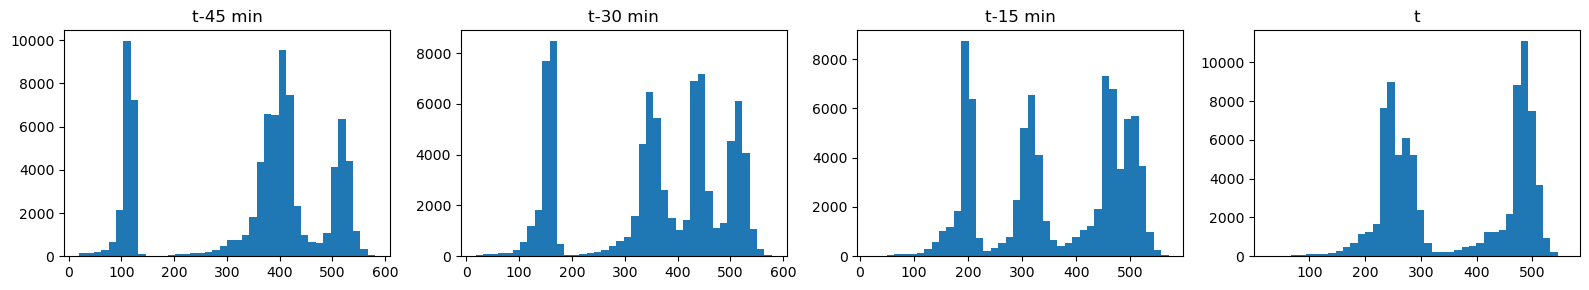

In [29]:
# %% Distributions par frame passée
fig, axes = plt.subplots(1, data["X"]["GHI"].shape[1], figsize=(16, 3))
for i in range(data["X"]["GHI"].shape[1]):
    vals = np.asarray(data["X"]["GHI"][:, i]).ravel()
    vals = vals[np.isfinite(vals)]
    axes[i].hist(vals, bins=40)
    axes[i].set_title(past_titles[i])
plt.tight_layout()
plt.show()

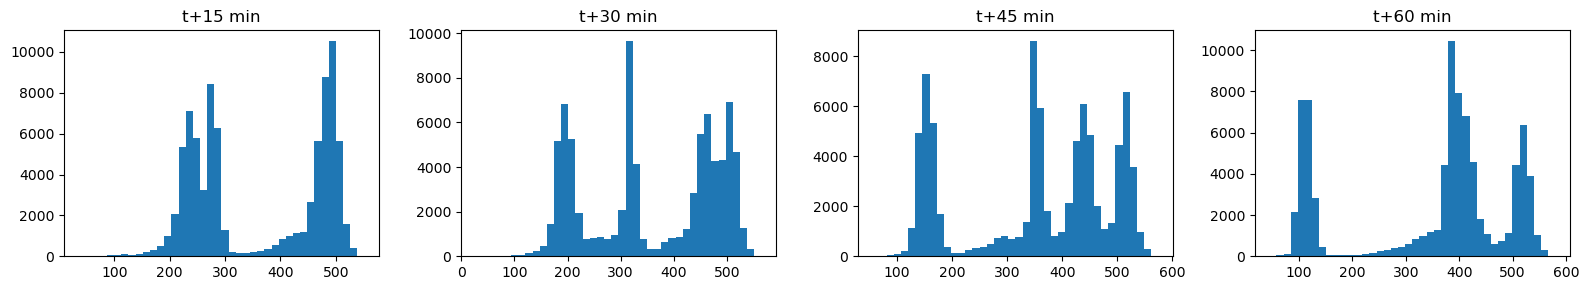

In [30]:
# %% Distributions par horizon futur
fig, axes = plt.subplots(1, data["y"].shape[1], figsize=(16, 3))
for i, horizon in enumerate(FORECAST_HORIZONS_MINUTES):
    vals = np.asarray(data["y"][:, i]).ravel()
    vals = vals[np.isfinite(vals)]
    axes[i].hist(vals, bins=40)
    axes[i].set_title(f"t+{horizon} min")
plt.tight_layout()
plt.show()

### 11.2 EDA de la représentation physique

Comme le pipeline de modélisation repose désormais sur `CSI`, `CLS` et les angles encodés,
l'EDA doit aussi porter sur ces variables transformées.

On s'intéresse ici à :
- la distribution de `CSI`,
- sa dynamique temporelle,
- les relations agrégées entre `CSI`, `CLS` et la cible,
- le comportement des angles encodés.

,variable,shape,mean,std,min,median,max
0,CSI,"(25, 4, 51, 51)",0.902746,0.093081,0.103893,0.937731,0.961201
1,CLS,"(25, 8, 51, 51)",383.335693,134.708633,95.919998,409.829987,605.140015
2,SZA_sin,"(25, 8, 51, 51)",0.023439,0.531138,-0.801463,0.035074,0.802713
3,SZA_cos,"(25, 8, 51, 51)",-0.837321,0.127422,-0.999963,-0.851269,-0.596365
4,SAA_sin,"(25, 8, 51, 51)",0.920958,0.041633,0.856718,0.918584,0.991558
5,SAA_cos,"(25, 8, 51, 51)",0.371090,0.111333,0.129661,0.395225,0.515786


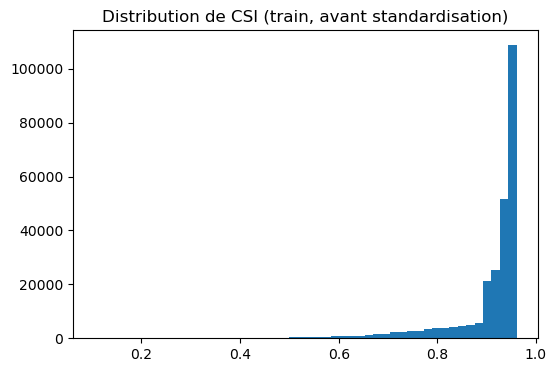

,variable,time_index,mean,std,min,max
0,CSI input,0,0.899106,0.095961,0.146619,0.961201
1,CSI input,1,0.901987,0.095133,0.103893,0.960563
2,CSI input,2,0.904028,0.092377,0.104262,0.959863
3,CSI input,3,0.905866,0.088535,0.105070,0.959003


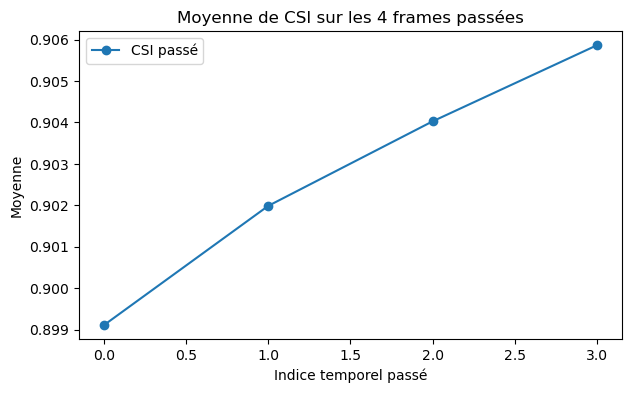

,CSI_mean,CLS_mean,SZA_sin_mean,SZA_cos_mean,SAA_sin_mean,SAA_cos_mean,target_mean
0,0.906423,270.213654,0.664208,-0.738293,0.955943,0.282387,324.015625
1,0.944200,490.773804,0.254329,-0.955205,0.883651,0.467022,496.233948
2,0.956041,486.067200,-0.273229,-0.950111,0.885463,0.463427,432.982269
3,0.939543,258.587219,-0.675704,-0.727993,0.958680,0.272563,163.644180
4,0.848912,274.191040,0.666042,-0.736647,0.955902,0.282463,316.708954


,CSI_mean,CLS_mean,SZA_sin_mean,SZA_cos_mean,SAA_sin_mean,SAA_cos_mean,target_mean
CSI_mean,1.000000,0.263428,-0.443595,-0.275471,-0.261328,0.260951,0.159922
CLS_mean,0.263428,1.000000,-0.035047,-0.997843,-0.999088,0.999001,0.883231
SZA_sin_mean,-0.443595,-0.035047,1.000000,0.036472,0.036645,-0.032530,0.414214
SZA_cos_mean,-0.275471,-0.997843,0.036472,1.000000,0.999339,-0.999387,-0.882572
SAA_sin_mean,-0.261328,-0.999088,0.036645,0.999339,1.000000,-0.999947,-0.881318
SAA_cos_mean,0.260951,0.999001,-0.032530,-0.999387,-0.999947,1.000000,0.883366
target_mean,0.159922,0.883231,0.414214,-0.882572,-0.881318,0.883366,1.000000


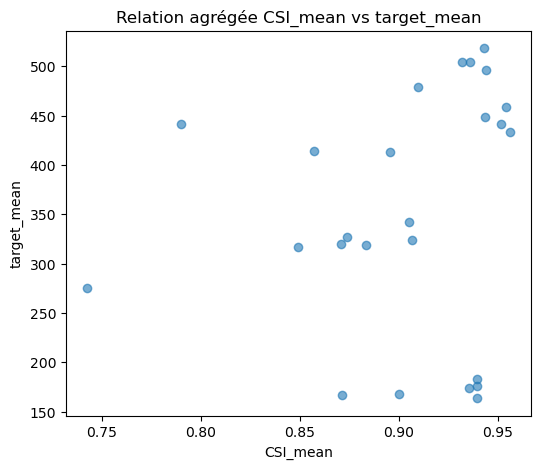

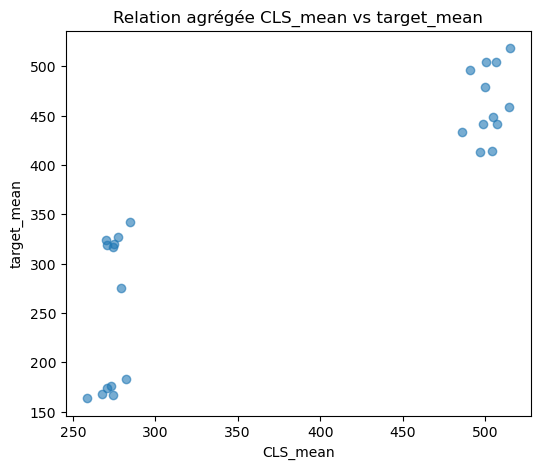

In [31]:
# %% Statistiques descriptives - représentation physique
display(descriptive_stats(train_arrays_phys))

# %% Distribution de CSI
if "CSI" in train_arrays_phys:
    plot_value_distribution(train_arrays_phys["CSI"], title="Distribution de CSI (train, avant standardisation)")
    plt.show()

# %% Dynamique temporelle de CSI
if "CSI" in train_arrays_phys:
    csi_time_summary = temporal_ghi_summary(train_arrays_phys["CSI"], label="CSI input")
    display(csi_time_summary)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(csi_time_summary["time_index"], csi_time_summary["mean"], marker="o", label="CSI passé")
    ax.set_xlabel("Indice temporel passé")
    ax.set_ylabel("Moyenne")
    ax.set_title("Moyenne de CSI sur les 4 frames passées")
    ax.legend()
    plt.show()

# %% Analyse agrégée des variables physiques transformées
sample_means_phys = sample_level_means(train_arrays_phys, y=train_target)
display(sample_means_phys.head())
display(sample_means_phys.corr())

# %% Scatter plots utiles
if "CSI_mean" in sample_means_phys.columns:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(sample_means_phys["CSI_mean"], sample_means_phys["target_mean"], alpha=0.6)
    ax.set_xlabel("CSI_mean")
    ax.set_ylabel("target_mean")
    ax.set_title("Relation agrégée CSI_mean vs target_mean")
    plt.show()

if "CLS_mean" in sample_means_phys.columns:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(sample_means_phys["CLS_mean"], sample_means_phys["target_mean"], alpha=0.6)
    ax.set_xlabel("CLS_mean")
    ax.set_ylabel("target_mean")
    ax.set_title("Relation agrégée CLS_mean vs target_mean")
    plt.show()

Comme le pipeline repose sur une représentation physiquement informée, il est utile d'explorer directement le `CSI`.

Le `CSI` mesure l'irradiance observée relativement à l'irradiance de ciel clair :
- `CSI ≈ 1` : situation proche du ciel clair ;
- `CSI < 1` : atténuation liée à la couverture nuageuse ;
- variations temporelles de `CSI` : dynamique récente des nuages.

Cette variable devient l'une des composantes centrales des futurs modèles.

### 11.3 Analyse des features de modélisation

On examine ici les objets qui serviront directement aux modèles :
- le tenseur spatial pour les modèles CNN ;
- les features tabulaires pour les modèles classiques, le clustering et l'interprétabilité.

In [32]:
# %% Analyse des canaux du tenseur spatial
feature_channel_stats = pd.DataFrame(
    {
        "feature": feature_names,
        "mean": feature_tensor.mean(axis=(0, 2, 3)),
        "std": feature_tensor.std(axis=(0, 2, 3)),
        "min": feature_tensor.min(axis=(0, 2, 3)),
        "max": feature_tensor.max(axis=(0, 2, 3)),
    }
)
display(feature_channel_stats.head(30))

# %% Corrélations entre features spatiales agrégées
feature_means_df = pd.DataFrame(
    {
        feature_names[i]: feature_tensor[:, i].mean(axis=(1, 2))
        for i in range(feature_tensor.shape[1])
    }
)
display(feature_means_df.corr().iloc[:15, :15])

# %% Analyse rapide des features tabulaires
tabular_stats = tabular_features_train.describe().T
display(tabular_stats.head(30))

# %% Corrélations tabulaires
display(tabular_features_train.corr().iloc[:20, :20])

,feature,mean,std,min,max
0,CSI_t0,-0.039111,1.030949,-8.123368,0.628001
1,CSI_t1,-0.008163,1.022048,-8.582390,0.621146
2,CSI_t2,0.013766,0.992437,-8.578430,0.613629
3,CSI_t3,0.033509,0.951168,-8.569750,0.604381
4,CLS_t0,-0.109589,1.166323,-2.043935,1.646549
5,CLS_t1,-0.037562,1.040369,-1.724802,1.620269
6,CLS_t2,0.015073,0.940131,-1.404035,1.564074
7,CLS_t3,0.047075,0.880343,-1.091063,1.477740
8,CLS_t4,0.057844,0.872071,-1.209913,1.449085
9,CLS_t5,0.047290,0.916848,-1.514644,1.543734


,CSI_t0,CSI_t1,CSI_t2,CSI_t3,CLS_t0,CLS_t1,CLS_t2,CLS_t3,CLS_t4,CLS_t5,CLS_t6,CLS_t7,SZA_sin_t0,SZA_sin_t1,SZA_sin_t2
CSI_t0,1.000000,0.991975,0.975652,0.948121,0.564029,0.524484,0.455129,0.347889,0.208884,0.061983,-0.067995,-0.170932,-0.511595,-0.518883,-0.526095
CSI_t1,0.991975,1.000000,0.995134,0.978670,0.512180,0.479254,0.419896,0.326455,0.203778,0.072867,-0.043867,-0.136922,-0.450237,-0.457222,-0.464146
CSI_t2,0.975652,0.995134,1.000000,0.993567,0.461439,0.434559,0.384476,0.303989,0.196794,0.081185,-0.022776,-0.106228,-0.392328,-0.398998,-0.405608
CSI_t3,0.948121,0.978670,0.993567,1.000000,0.394282,0.377612,0.342475,0.282033,0.197939,0.104395,0.018273,-0.052181,-0.305466,-0.311949,-0.318375
CLS_t0,0.564029,0.512180,0.461439,0.394282,1.000000,0.986519,0.932275,0.816809,0.637506,0.423979,0.217912,0.043362,-0.639015,-0.657748,-0.676474
CLS_t1,0.524484,0.479254,0.434559,0.377612,0.986519,1.000000,0.978905,0.900204,0.754989,0.566468,0.374682,0.206264,-0.504544,-0.525632,-0.546851
CLS_t2,0.455129,0.419896,0.384476,0.342475,0.932275,0.978905,1.000000,0.970187,0.873038,0.722890,0.556207,0.401832,-0.317515,-0.340749,-0.364279
CLS_t3,0.347889,0.326455,0.303989,0.282033,0.816809,0.900204,0.970187,1.000000,0.965196,0.868798,0.741035,0.611781,-0.078250,-0.102757,-0.127740
CLS_t4,0.208884,0.203778,0.196794,0.197939,0.637506,0.754989,0.873038,0.965196,1.000000,0.968060,0.890850,0.797362,0.185180,0.160939,0.136061
CLS_t5,0.061983,0.072867,0.081185,0.104395,0.423979,0.566468,0.722890,0.868798,0.968060,1.000000,0.976297,0.923203,0.425632,0.403230,0.380078


,count,mean,std,min,25%,50%,75%,max
CSI_mean_t0,25.0,-3.911119e-02,0.582905,-1.602822,-0.364088,0.098520,0.427177,0.571499
CSI_std_t0,25.0,6.835766e-01,0.529733,0.090080,0.241271,0.467673,1.082091,1.929876
CSI_min_t0,25.0,-3.839240e+00,2.421005,-8.123368,-5.717928,-3.663721,-1.681128,-1.054881
CSI_max_t0,25.0,3.958635e-01,0.265129,-0.034386,-0.009575,0.502949,0.557758,0.628001
CSI_mean_t1,25.0,-8.163385e-03,0.579392,-1.759526,-0.316135,0.104317,0.425957,0.575434
CSI_std_t1,25.0,6.738328e-01,0.528623,0.088813,0.264283,0.421793,1.153425,1.924350
CSI_min_t1,25.0,-3.907542e+00,2.596503,-8.582390,-6.096006,-3.126167,-1.674577,-0.692269
CSI_max_t1,25.0,4.283871e-01,0.203105,0.106614,0.127459,0.471073,0.579282,0.621146
CSI_mean_t2,25.0,1.376558e-02,0.572542,-1.804202,-0.280149,0.103543,0.379750,0.573271
CSI_std_t2,25.0,6.483234e-01,0.510225,0.072863,0.306663,0.408409,1.039446,1.783289


,CSI_mean_t0,CSI_std_t0,CSI_min_t0,CSI_max_t0,CSI_mean_t1,CSI_std_t1,CSI_min_t1,CSI_max_t1,CSI_mean_t2,CSI_std_t2,CSI_min_t2,CSI_max_t2,CSI_mean_t3,CSI_std_t3,CSI_min_t3,CSI_max_t3,CSI_mean_global,CSI_std_global,CSI_trend_last_minus_first,CSI_q25_t0
CSI_mean_t0,1.000000,-0.708463,0.698627,0.586396,0.991975,-0.734184,0.722786,0.563905,0.975652,-0.739494,0.735025,0.505694,0.948121,-0.743229,0.700869,0.362587,0.986588,-0.738035,-0.341759,0.905709
CSI_std_t0,-0.708463,1.000000,-0.937190,-0.274329,-0.694417,0.993755,-0.936995,-0.251598,-0.674131,0.976036,-0.942182,-0.205994,-0.658126,0.951162,-0.943299,-0.115746,-0.689223,0.988690,0.282277,-0.447043
CSI_min_t0,0.698627,-0.937190,1.000000,0.332438,0.693746,-0.929682,0.985635,0.339498,0.682620,-0.903340,0.966996,0.341141,0.677971,-0.873637,0.938926,0.310634,0.693465,-0.920062,-0.192679,0.475048
CSI_max_t0,0.586396,-0.274329,0.332438,1.000000,0.533455,-0.313557,0.323421,0.991194,0.479600,-0.322907,0.341295,0.938989,0.405908,-0.311495,0.348741,0.769282,0.506538,-0.315607,-0.644022,0.373207
CSI_mean_t1,0.991975,-0.694417,0.693746,0.533455,1.000000,-0.719480,0.723094,0.515999,0.995134,-0.721894,0.734634,0.468757,0.978670,-0.730549,0.696523,0.345227,0.998885,-0.722164,-0.226216,0.920619
CSI_std_t1,-0.734184,0.993755,-0.929682,-0.313557,-0.719480,1.000000,-0.939540,-0.289919,-0.699024,0.992522,-0.952214,-0.240616,-0.682004,0.975284,-0.960086,-0.141364,-0.714310,0.998136,0.292571,-0.471783
CSI_min_t1,0.722786,-0.936995,0.985635,0.323421,0.723094,-0.939540,1.000000,0.328289,0.716067,-0.922342,0.992821,0.326684,0.713783,-0.900656,0.966877,0.291950,0.724292,-0.933488,-0.162785,0.502984
CSI_max_t1,0.563905,-0.251598,0.339498,0.991194,0.515999,-0.289919,0.328289,1.000000,0.466674,-0.294546,0.339146,0.976062,0.400657,-0.278902,0.345987,0.846518,0.491754,-0.289154,-0.588822,0.366673
CSI_mean_t2,0.975652,-0.674131,0.682620,0.479600,0.995134,-0.699024,0.716067,0.466674,1.000000,-0.701742,0.726217,0.429639,0.993567,-0.714986,0.684395,0.324903,0.998273,-0.702168,-0.130851,0.926219
CSI_std_t2,-0.739494,0.976036,-0.903340,-0.322907,-0.721894,0.992522,-0.922342,-0.294546,-0.701742,1.000000,-0.942661,-0.236670,-0.684484,0.993098,-0.956376,-0.124761,-0.717580,0.997390,0.301938,-0.479461


## 12. Métriques d'évaluation

Les futurs modèles seront comparés à l'aide de métriques de régression adaptées à la prévision d'images :

- **RMSE** : pénalise davantage les grosses erreurs ;
- **MAE** : plus robuste et plus directement interprétable.

Comme la cible est multi-horizon, il faut calculer :
- des scores globaux ;
- des scores par horizon de prévision ;
- éventuellement, plus tard, des scores sur des agrégats spatiaux.

In [33]:
# %% Sanity check des métriques sur une prédiction triviale

dummy_pred = np.zeros_like(val_target)

print("Scores globaux - prédiction nulle")
display(evaluate_forecasts(val_target, dummy_pred))

print("Scores par horizon - prédiction nulle")
display(evaluate_by_horizon(val_target, dummy_pred))

print("Scores sur moyennes spatiales - prédiction nulle")
display(evaluate_spatial_means(val_target, dummy_pred))

Scores globaux - prédiction nulle


,metric,value
0,RMSE,392.485415
1,MAE,367.200385


Scores par horizon - prédiction nulle


,horizon_min,RMSE,MAE
0,15,398.994495,380.848920
1,30,395.346910,373.443357
2,45,390.693096,363.697722
3,60,384.762683,350.811542


Scores sur moyennes spatiales - prédiction nulle


,horizon_min,RMSE_spatial_mean,MAE_spatial_mean
0,15,397.920551,380.848903
1,30,394.299371,373.443351
2,45,389.692119,363.697730
3,60,383.795087,350.811534


## 13. Conclusion intermédiaire

À ce stade, on dispose de trois objets réutilisables :
- `train_arrays_std` / `val_arrays_std` : représentation physique standardisée ;
- `feature_tensor` : tenseur spatial pour modèles CNN ;
- `tabular_features_train` / `tabular_features_val` : représentation tabulaire pour modèles classiques.

Ces objets serviront directement à la construction des baselines, des modèles supervisés, du clustering et des analyses d'interprétabilité.

### Suite logique du projet
Les prochains notebooks pourront se concentrer sur :
1. les métriques d'évaluation (`RMSE`, `MAE`, globales et par horizon) ;
2. une ou plusieurs **baselines simples** ;
3. des modèles supervisés classiques ;
4. un modèle non supervisé / clustering pour répondre à la consigne du cours ;
5. l'interprétation des modèles (importance, PDP, SHAP, etc.) ;
6. éventuellement un modèle deep learning.

In [34]:
prepared_objects = pd.DataFrame(
    [
        {"object": "train_arrays_std", "type": "dict[str, np.ndarray]", "usage": "représentation physique standardisée (train)"},
        {"object": "val_arrays_std", "type": "dict[str, np.ndarray]", "usage": "représentation physique standardisée (validation)"},
        {"object": "feature_tensor", "type": "np.ndarray", "usage": "tenseur spatial pour CNN / modèles image"},
        {"object": "feature_names", "type": "list[str]", "usage": "noms des canaux du tenseur spatial"},
        {"object": "tabular_features_train", "type": "pd.DataFrame", "usage": "features tabulaires pour modèles classiques"},
        {"object": "tabular_features_val", "type": "pd.DataFrame", "usage": "features tabulaires pour validation"},
        {"object": "train_target", "type": "np.ndarray", "usage": "cible train"},
        {"object": "val_target", "type": "np.ndarray", "usage": "cible validation"},
    ]
)
display(prepared_objects)

,object,type,usage
0,train_arrays_std,"dict[str, np.ndarray]",représentation physique standardisée (train)
1,val_arrays_std,"dict[str, np.ndarray]",représentation physique standardisée (validation)
2,feature_tensor,np.ndarray,tenseur spatial pour CNN / modèles image
3,feature_names,list[str],noms des canaux du tenseur spatial
4,tabular_features_train,pd.DataFrame,features tabulaires pour modèles classiques
5,tabular_features_val,pd.DataFrame,features tabulaires pour validation
6,train_target,np.ndarray,cible train
7,val_target,np.ndarray,cible validation


## Annexe — commandes utiles pour construire les profils lourds

À lancer seulement quand le pipeline est stabilisé.

In [35]:

# prepare_processed_profile("sample", split="train")
# prepare_processed_profile("sample", split="test", include_target=False)

# prepare_processed_profile("full", split="train")
# prepare_processed_profile("full", split="test", include_target=False)